# 07 - Final Evaluation & Publication-Ready Results

This notebook performs the final evaluation on the held-out test set:
1. Load the best model and selected features
2. Evaluate on untouched test data
3. Compute Bootstrap 95% Confidence Intervals
4. Generate publication-quality figures (ROC, PR, Calibration, Confusion Matrix)
5. Save all final results for the manuscript

> **Critical Rule:** Test data has been completely untouched until this point.
> All preprocessing, feature selection, and feature engineering were fit on the
> training set only. The pre-engineered, pre-selected test matrix produced at
> the end of Notebook 05 (`X_test_selected.csv`) is loaded directly here so
> that its column names match the trained model exactly.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import numpy as np
import pandas as pd

import config
from src.io import load_model, save_table, save_figure, logger
from src.models import xgb_safe_frame, requires_xgb_safe
from src.evaluation import compute_metrics, stratified_bootstrap_auc
from src.visualization import (
    setup_style,
    plot_roc_curve,
    plot_pr_curve,
    plot_calibration,
    plot_confusion_matrix,
)
from src.validation import verify_pipeline_consistency

setup_style()
print(" Libraries imported successfully.")

 Libraries imported successfully.


## Step 1: Load Final Model and Data

In [2]:
# Run pipeline consistency check before loading model.
# This guards against exactly the kind of train/test feature-name drift
# (e.g. duplicate engineered columns getting deduped differently at
# train time vs. test time) that caused the mismatch fixed below.
print("Running pipeline consistency check...\n")
consistency = verify_pipeline_consistency(config)

if not consistency["passed"]:
    print("❌ Pipeline consistency check FAILED:")
    for issue in consistency["issues"]:
        print(f"  - {issue}")
    raise RuntimeError("Fix the above issues before proceeding with evaluation")
else:
    print("✅ Pipeline consistency check PASSED")
    print(f"   Artifacts: {consistency['artifacts']}")

Running pipeline consistency check...

✅ Pipeline consistency check PASSED
   Artifacts: {'final_feature_count': 47, 'pso_feature_count': 40, 'test_sample_count': 86, 'test_feature_count': 47, 'model_exists': True}


In [3]:
# Load the best model
model = load_model("best_model_xgboost.joblib")
model_name = "XGBoost + PSO"

# Load the FINAL feature list
selected_features_df = pd.read_csv(config.TABLES_DIR / "selected_features_final.csv")
selected_features = selected_features_df["feature"].tolist()

# Load PRE-ENGINEERED test data directly from Notebook 05's output.
# IMPORTANT: this file already contains the same engineered/deduplicated
# columns that the model was trained on, so we do NOT re-run
# create_engineered_features() here -- doing so previously produced a
# duplicate 'High_Risk_Gleason' column that got deduplicated differently
# at train time ('High_Risk_Gleason_2') vs. at CSV-reload time
# ('High_Risk_Gleason.1'), causing a feature_names mismatch in XGBoost.
X_test_final = pd.read_csv(config.PROCESSED_DIR / "X_test_selected.csv")
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]

# Apply the same XGBoost-safe column-name sanitization used at training time.
X_test_final = xgb_safe_frame(X_test_final)

# Verify feature names match exactly what the model was trained on.
expected_features = model.get_booster().feature_names
if list(X_test_final.columns) != expected_features:
    raise ValueError(
        f"Feature mismatch! Model expects {expected_features}, "
        f"got {list(X_test_final.columns)}"
    )

# Validate feature count matches model expectation
if X_test_final.shape[1] != model.n_features_in_:
    raise ValueError(
        f"Feature count mismatch: model expects {model.n_features_in_}, "
        f"got {X_test_final.shape[1]}"
    )

logger.info(f"Loaded test data: {X_test_final.shape[0]} samples, {X_test_final.shape[1]} features")
logger.info("Feature validation passed - ready for prediction")

2026-08-23 20:00:28 | INFO     | prostate_bcr | Loading model from D:\Prostate_BCR\core\outputs\models\best_model_xgboost.joblib
2026-08-23 20:00:28 | INFO     | prostate_bcr | Loaded test data: 86 samples, 47 features
2026-08-23 20:00:28 | INFO     | prostate_bcr | Feature validation passed - ready for prediction


## Step 2: Final Evaluation on Held-out Test Set

This is the **only time** the test data is used for evaluation.

In [4]:
print("Generating predictions and finding optimal threshold...")

# Generate probabilities.
# X_test_final was already sanitized in the loading step (Cell above),
# so we predict directly rather than calling xgb_safe_frame() a second time.
y_prob = model.predict_proba(X_test_final)[:, 1]

# Find optimal threshold (Sensitivity >= 0.75 with max Youden's J)
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob, drop_intermediate=False)
n = min(len(thresholds), len(tpr) - 1, len(fpr) - 1)

cand = pd.DataFrame({
    "threshold": thresholds[:n],
    "sensitivity": tpr[1:n+1],
    "specificity": 1 - fpr[1:n+1],
})
cand["youden_j"] = cand.sensitivity + cand.specificity - 1

eligible = cand[cand.sensitivity >= 0.75]
if len(eligible) == 0:
    print(" No threshold achieves Sens ≥ 0.75, falling back to Youden's J")
    point = cand.loc[cand["youden_j"].idxmax()]
else:
    point = eligible.sort_values("youden_j", ascending=False).iloc[0]

optimal_threshold = float(point.threshold)

print(f"Selected Threshold: {optimal_threshold:.4f} (Sens={point.sensitivity:.3f}, Spec={point.specificity:.3f})")

# Compute final metrics
y_pred = (y_prob >= optimal_threshold).astype(int)
metrics = compute_metrics(y_test, y_pred, y_prob, threshold=optimal_threshold)

print("\n" + "="*60)
print(f"FINAL EVALUATION: {model_name}")
print("="*60)
for k, v in metrics.items():
    if isinstance(v, float): print(f"  {k:25s}: {v:.4f}")
    else: print(f"  {k:25s}: {v}")
print("="*60)

Generating predictions and finding optimal threshold...
Selected Threshold: 0.1384 (Sens=0.833, Spec=0.635)

FINAL EVALUATION: XGBoost + PSO
  accuracy                 : 0.6512
  precision                : 0.2500
  recall                   : 0.7500
  sensitivity              : 0.7500
  f1                       : 0.3750
  mcc                      : 0.2705
  balanced_accuracy        : 0.6926
  specificity              : 0.6351
  true_negative            : 47
  false_positive           : 27
  false_negative           : 3
  true_positive            : 9
  roc_auc                  : 0.8007
  pr_auc                   : 0.4340


## Step 3: Bootstrap 95% Confidence Intervals

Stratified bootstrap resampling to estimate the confidence interval for ROC-AUC.

2026-08-23 20:00:32 | INFO     | prostate_bcr | Bootstrap AUC CI (95%): [0.6520, 0.9212]



Bootstrap 95% CI for ROC-AUC:
  Point estimate: 0.8007
  95% CI:         [0.6520, 0.9212]
  Bootstrap samples: 3000


2026-08-23 20:00:32 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\bootstrap_auc_distribution.png


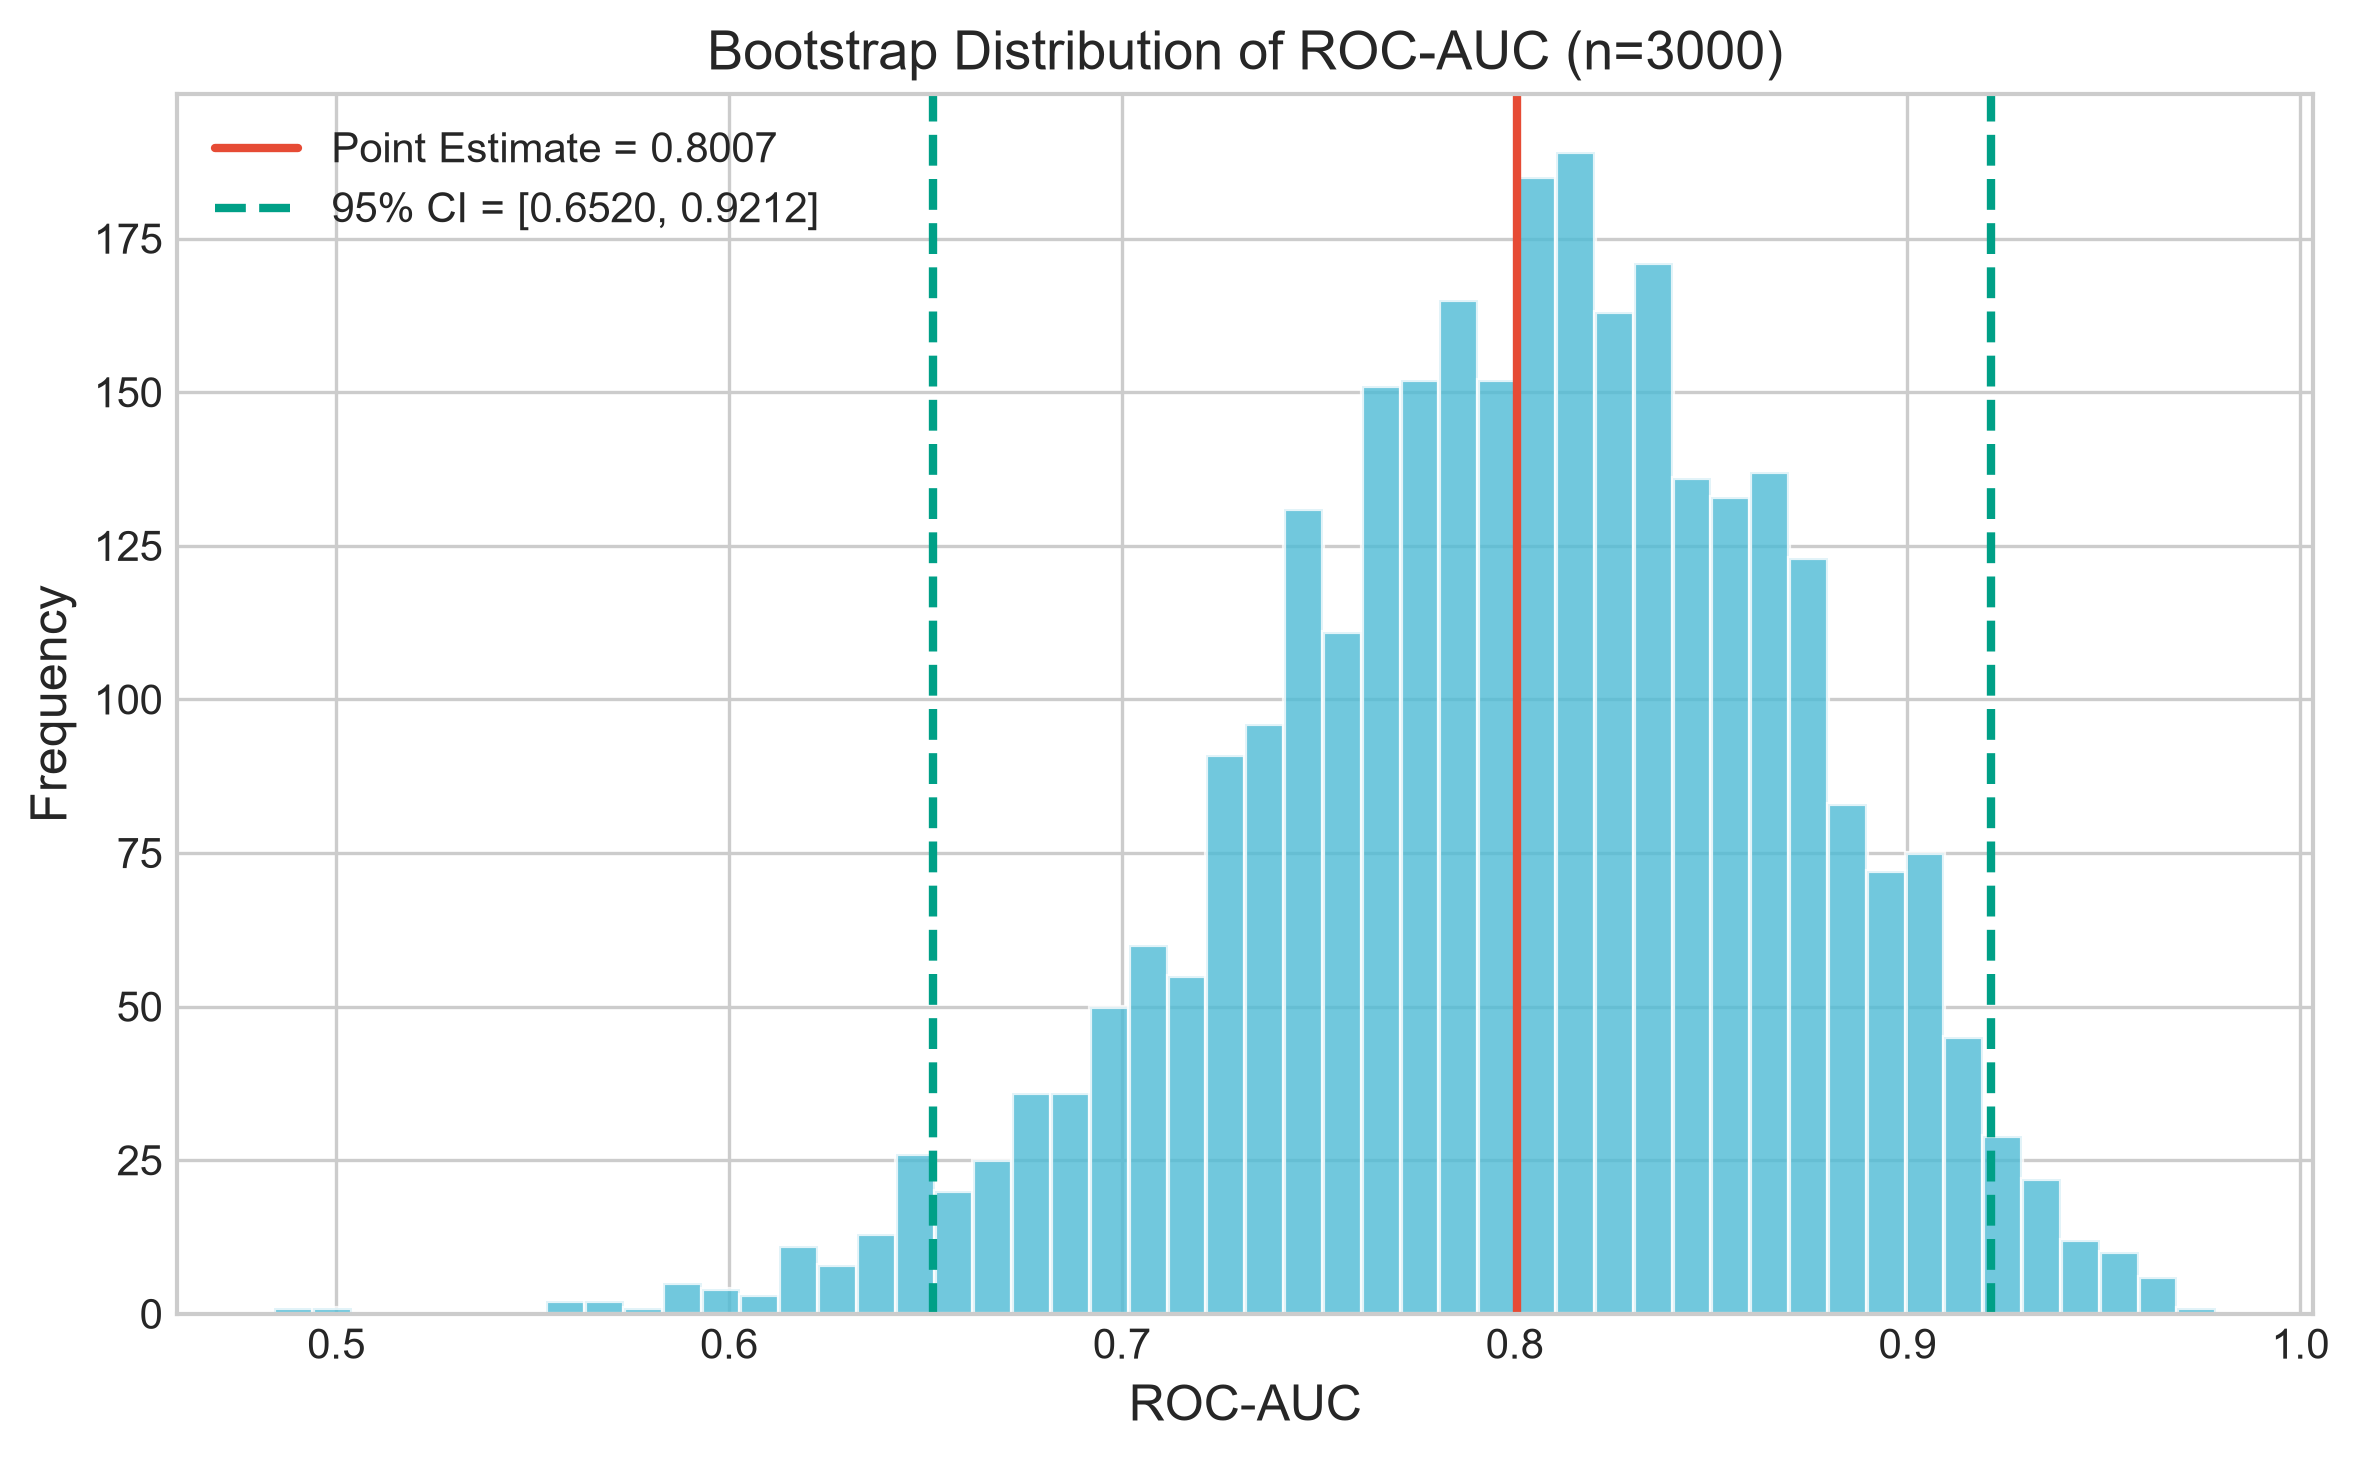

In [5]:
import matplotlib.pyplot as plt

# Compute bootstrap CI for ROC-AUC
(ci_low, ci_high), bootstrap_scores = stratified_bootstrap_auc(
    y_test,
    y_prob,
    n_boot=config.BOOTSTRAP_N,
    random_state=config.RANDOM_STATE,
)

print(f"\nBootstrap 95% CI for ROC-AUC:")
print(f"  Point estimate: {metrics['roc_auc']:.4f}")
print(f"  95% CI:         [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  Bootstrap samples: {len(bootstrap_scores)}")

# Visualize bootstrap distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bootstrap_scores, bins=50, color="#4DBBD5", edgecolor="white", alpha=0.8)
ax.axvline(metrics["roc_auc"], color="#E64B35", linewidth=2, linestyle="-", label=f"Point Estimate = {metrics['roc_auc']:.4f}")
ax.axvline(ci_low, color="#00A087", linewidth=2, linestyle="--", label=f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")
ax.axvline(ci_high, color="#00A087", linewidth=2, linestyle="--")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of ROC-AUC (n=3000)")
ax.legend(framealpha=0.9)
plt.tight_layout()
save_figure(fig, "bootstrap_auc_distribution.png")
plt.show()

## Step 4: Publication-Quality Figures

Generate all figures for the manuscript at 300 DPI.

In [6]:
import matplotlib.pyplot as plt
from src.visualization import plot_roc_curve, plot_pr_curve, plot_calibration, plot_confusion_matrix

# --- ROC Curve ---
fig_roc = plot_roc_curve(
    y_test,
    y_prob,
    model_name=model_name,
    filename="final_roc_curve.png",
    figsize=(7, 6)
)
plt.show()

# --- PR Curve ---
fig_pr = plot_pr_curve(
    y_test,
    y_prob,
    model_name=model_name,
    filename="final_pr_curve.png",
    figsize=(7, 6)
)
plt.show()

# --- Calibration Curve ---
fig_cal = plot_calibration(
    y_test,
    y_prob,
    model_name=model_name,
    n_bins=10,
    filename="final_calibration_plot.png",
    figsize=(7, 6)
)
plt.show()

# --- Confusion Matrix ---
fig_cm = plot_confusion_matrix(
    y_test,
    y_pred,
    filename="final_confusion_matrix.png",
    figsize=(6, 5)
)
plt.show()

cm_df = pd.DataFrame(
    [[metrics["true_negative"], metrics["false_positive"]],
     [metrics["false_negative"], metrics["true_positive"]]],
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"],
)
print("\nConfusion Matrix:")
print(cm_df.to_string())

2026-08-23 20:00:32 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\final_roc_curve.png
2026-08-23 20:00:32 | INFO     | prostate_bcr | ROC curve plotted (AUC=0.8007)
2026-08-23 20:00:33 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\final_pr_curve.png
2026-08-23 20:00:33 | INFO     | prostate_bcr | PR curve plotted (PR-AUC=0.4340)
2026-08-23 20:00:33 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\final_calibration_plot.png
2026-08-23 20:00:33 | INFO     | prostate_bcr | Calibration plot generated
2026-08-23 20:00:33 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\final_confusion_matrix.png
2026-08-23 20:00:33 | INFO     | prostate_bcr | Confusion matrix plotted



Confusion Matrix:
                 Predicted Negative  Predicted Positive
Actual Negative                  47                  27
Actual Positive                   3                   9


## Step 5: Save Final Results

Save all metrics and results to JSON and CSV for the manuscript.

In [7]:
# Prepare final results dictionary.
# Note: keys here match exactly what compute_metrics() returns.
final_results = {
    "model_name": model_name,
    "n_test_samples": int(len(y_test)),
    "n_positive": int(y_test.sum()),
    "n_negative": int((y_test == 0).sum()),
    "positive_rate": f"{y_test.mean():.2%}",
    "n_selected_features": len(selected_features),
    "metrics": {
        "roc_auc": round(metrics["roc_auc"], 4),
        "pr_auc": round(metrics["pr_auc"], 4),
        "accuracy": round(metrics["accuracy"], 4),
        "precision": round(metrics["precision"], 4),
        "recall": round(metrics["recall"], 4),
        "sensitivity": round(metrics["sensitivity"], 4),
        "specificity": round(metrics["specificity"], 4),
        "f1_score": round(metrics["f1"], 4),  # note: key is 'f1', not 'f1_score'
        "mcc": round(metrics["mcc"], 4),
        "balanced_accuracy": round(metrics["balanced_accuracy"], 4),
    },
    "confusion_matrix": {
        "true_negative": int(metrics["true_negative"]),
        "false_positive": int(metrics["false_positive"]),
        "false_negative": int(metrics["false_negative"]),
        "true_positive": int(metrics["true_positive"]),
    }
}

try:
    final_results['metrics']['roc_auc_ci_low'] = round(ci_low, 4)
    final_results['metrics']['roc_auc_ci_high'] = round(ci_high, 4)
except NameError:
    print("⚠️ Warning: CI values (ci_low, ci_high) not found. Skipping CI in JSON.")

# Save to JSON
with open(config.TABLES_DIR / "final_evaluation_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2)

# Save to CSV
results_df = pd.DataFrame([final_results["metrics"]])
results_df["model"] = model_name
save_table(results_df, "final_evaluation_metrics.csv", index=False)

print("Final results saved:")
print(f"  - final_evaluation_results.json")
print(f"  - final_evaluation_metrics.csv")
print("\nFinal Results Summary:")
print(json.dumps(final_results, ensure_ascii=False, indent=2))

2026-08-23 20:00:33 | INFO     | prostate_bcr | Saved 1 rows → D:\Prostate_BCR\core\outputs\tables\final_evaluation_metrics.csv


Final results saved:
  - final_evaluation_results.json
  - final_evaluation_metrics.csv

Final Results Summary:
{
  "model_name": "XGBoost + PSO",
  "n_test_samples": 86,
  "n_positive": 12,
  "n_negative": 74,
  "positive_rate": "13.95%",
  "n_selected_features": 47,
  "metrics": {
    "roc_auc": 0.8007,
    "pr_auc": 0.434,
    "accuracy": 0.6512,
    "precision": 0.25,
    "recall": 0.75,
    "sensitivity": 0.75,
    "specificity": 0.6351,
    "f1_score": 0.375,
    "mcc": 0.2705,
    "balanced_accuracy": 0.6926,
    "roc_auc_ci_low": 0.652,
    "roc_auc_ci_high": 0.9212
  },
  "confusion_matrix": {
    "true_negative": 47,
    "false_positive": 27,
    "false_negative": 3,
    "true_positive": 9
  }
}


### Publication Outputs

All figures saved to `outputs/figures/` at 300 DPI:
- `final_roc_curve.png`
- `final_pr_curve.png`
- `final_calibration_plot.png`
- `final_confusion_matrix.png`
- `bootstrap_auc_distribution.png`

All tables saved to `outputs/tables/`:
- `final_evaluation_results.json`
- `final_evaluation_metrics.csv`
- `selected_features.csv`
- `feature_importance_full.csv`
- `biomarker_ranking_genes.csv`

---